# Beyond GDP: Using PCA to Uncover the Hidden Dimensions of World Happiness

---
**Name:** Guhan Dhakshanamurthy  
**Student Number:** 24169000  
**Technique:** Principal Component Analysis (PCA)  
**Dataset:** World Happiness Report 2026 — 2025 Rankings (145 countries)  
**GitHub:** https://github.com/guhan-ac/world-happiness-pca

---

## What This Tutorial Covers

Every year, the United Nations surveys people in 140+ countries and asks a simple question: *on a scale of 0 to 10, how good is your life?* The answers are broken down into six factors — wealth, social support, health, freedom, generosity, and trust in institutions.

Six correlated variables are hard to visualise or reason about all at once. **Principal Component Analysis (PCA)** solves this by finding new axes that capture the most variation in the data, letting us compress six dimensions into two without losing too much information.

---

## References

1. Helliwell et al. (2026). *World Happiness Report 2026*. University of Oxford. https://worldhappiness.report/
2. Pearson, K. (1901). On lines and planes of closest fit. *Philosophical Magazine*, 2(11), 559–572. https://doi.org/10.1080/14786440109462720
3. Hotelling, H. (1933). Analysis of a complex of statistical variables into principal components. *Journal of Educational Psychology*, 24(6), 417–441.
4. Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
5. Jolliffe & Cadima (2016). PCA: a review and recent developments. *Phil. Trans. R. Soc. A*, 374(2065). https://pmc.ncbi.nlm.nih.gov/articles/PMC4792409/
6. scikit-learn (2024). *sklearn.decomposition.PCA*. https://scikit-learn.org/stable/modules/decomposition.html#pca
7. Wong, B. (2011). Color blindness. *Nature Methods*, 8(6), 441. https://doi.org/10.1038/nmeth.1618

---
## Step 1 — Import Libraries


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

CB = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00', '#F0E442', '#000000']

plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 12,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 12,
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#F8F8F8',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

print('Libraries loaded successfully.')
print('Colour-blind-safe palette active (Okabe-Ito / Wong 2011).')

Libraries loaded successfully.
Colour-blind-safe palette active (Okabe-Ito / Wong 2011).


---
## Step 2 — Load the Dataset

We use `world_happiness_2025.csv`.  
This is the cleaned data from the **World Happiness Report 2026**, 2025 rankings.

### What the six features measure

Each feature represents the estimated *contribution* of that factor to a country's Cantril Ladder score (0 = worst possible life, 10 = best possible life):

| Feature | Short name | What it captures |
|---|---|---|
| `Explained by: Log GDP per capita` | GDP | Economic output per person |
| `Explained by: Social support` | Social Support | Having someone to count on |
| `Explained by: Healthy life expectancy` | Life Expectancy | Healthy years at birth |
| `Explained by: Freedom to make life choices` | Freedom | Satisfaction with personal freedom |
| `Explained by: Generosity` | Generosity | Charitable donations relative to GDP |
| `Explained by: Perceptions of corruption` | Low Corruption | Trust in government and business |

> **Note:** The happiness score (`Life evaluation (3-year average)`) is **not** used in the PCA — it is held aside as a validation variable to check our results at the end.

In [4]:
# Load data
df = pd.read_csv('data/world_happiness_2025.csv')

df = df.drop(columns=[c for c in df.columns if c.startswith('PC')], errors='ignore')

FEATURES = [
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption',
]
SHORT  = ['GDP', 'Social Support', 'Life Expectancy', 'Freedom', 'Generosity', 'Low Corruption']
TARGET = 'Life evaluation (3-year average)'   # happiness score — held out

REGION_COLOURS = {
    'Western Europe'            : '#0072B2',
    'North America & ANZ'       : '#56B4E9',
    'Latin America & Caribbean' : '#009E73',
    'Central & Eastern Europe'  : '#E69F00',
    'Middle East & North Africa': '#D55E00',
    'East Asia'                 : '#CC79A7',
    'Southeast Asia'            : '#8B4513',
    'South Asia'                : '#000000',
    'Sub-Saharan Africa'        : '#FF6B35',
    'Other'                     : '#AAAAAA',
}

print(f'Countries loaded : {len(df)}')
print(f'Happiest country : {df.loc[df[TARGET].idxmax(), "Country name"]}  '
      f'(score = {df[TARGET].max():.3f})')
print(f'Lowest country   : {df.loc[df[TARGET].idxmin(), "Country name"]}  '
      f'(score = {df[TARGET].min():.3f})')
print()
df[['Rank', 'Country name', TARGET, 'Region']].head(10)

Countries loaded : 145
Happiest country : Finland  (score = 7.764)
Lowest country   : Afghanistan  (score = 1.446)



,Rank,Country name,Life evaluation (3-year average),Region
0,1,Finland,7.764,Western Europe
1,2,Iceland,7.540,Western Europe
2,3,Denmark,7.539,Western Europe
3,4,Costa Rica,7.439,Latin America & Caribbean
4,5,Sweden,7.255,Western Europe
5,6,Norway,7.242,Western Europe
6,7,Netherlands,7.223,Western Europe
7,8,Israel,7.187,Middle East & North Africa
8,9,Luxembourg,7.063,Western Europe
9,10,Switzerland,7.018,Western Europe


---
## Step 3 — Exploratory Data Analysis

Before applying any machine learning technique, it is good practice to understand the data first.

Here we look at two things:
1. **Summary statistics** — to see the range and scale of each feature
2. **Correlation heatmap** — to check how much the features overlap

High correlations between features tell us there is *redundant information* in the data. This is exactly the condition where PCA helps most — it can compress that redundancy into fewer dimensions.

In [5]:
# Summary statistics — notice how scales differ across features
summary = df[FEATURES].copy()
summary.columns = SHORT
print('Summary statistics for the six WHR features:')
summary.describe().round(3)

Summary statistics for the six WHR features:


,GDP,Social Support,Life Expectancy,Freedom,Generosity,Low Corruption
count,145.000,145.000,145.000,145.000,145.000,145.000
mean,1.539,1.202,0.615,0.883,0.107,0.147
std,0.366,0.357,0.261,0.181,0.053,0.109
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.296,0.989,0.442,0.807,0.061,0.071
50%,1.582,1.286,0.606,0.914,0.107,0.115
75%,1.834,1.483,0.831,1.015,0.144,0.188
max,2.167,1.720,1.238,1.147,0.295,0.512


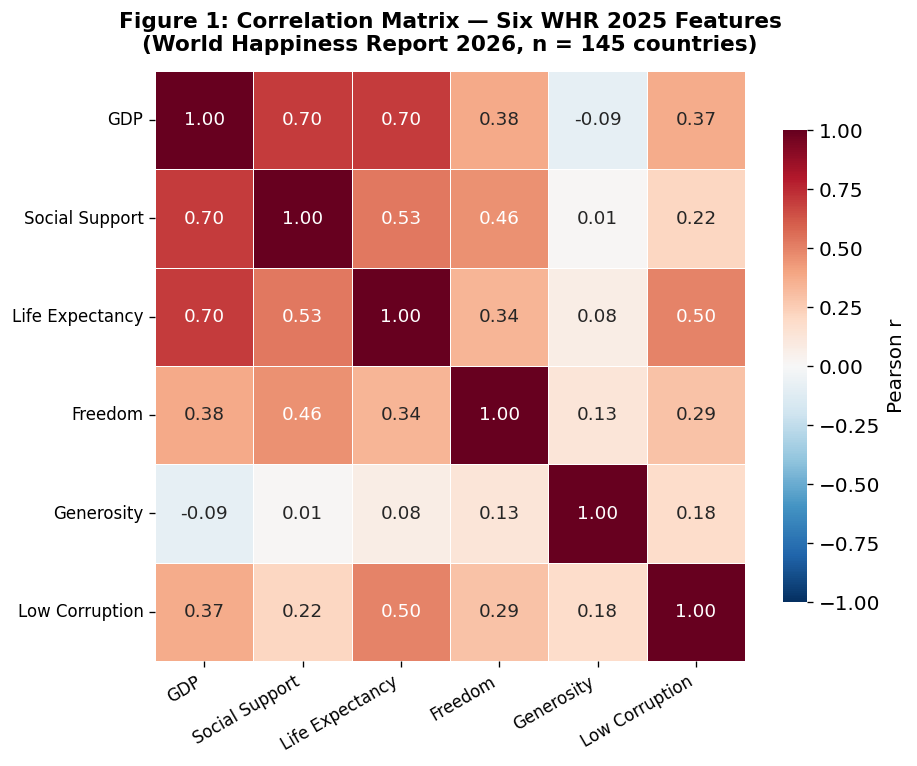

Feature pairs with |r| > 0.5  (strong overlap — PCA will compress these):
  GDP                   <->  Social Support         r = +0.696
  GDP                   <->  Life Expectancy        r = +0.696
  Social Support        <->  Life Expectancy        r = +0.528


In [6]:
# ── Figure 1: Correlation heatmap ─────────────────────────────────────────────
# Accessibility note: RdBu_r palette + numeric annotations
# so colour is never the only signal (meets WCAG 1.4.1)

corr = df[FEATURES].corr()
corr.index   = SHORT
corr.columns = SHORT

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
    annot_kws={'size': 11}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title(
    'Figure 1: Correlation Matrix — Six WHR 2025 Features\n'
    '(World Happiness Report 2026, n = 145 countries)',
    fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Print the strongest correlations numerically
print('Feature pairs with |r| > 0.5  (strong overlap — PCA will compress these):')
for i in range(len(SHORT)):
    for j in range(i+1, len(SHORT)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {SHORT[i]:20s}  <->  {SHORT[j]:20s}   r = {r:+.3f}')

### What Figure 1 tells us

- **GDP, Life Expectancy and Social Support** are all strongly correlated with each other (r > 0.6). This tells us these three features are measuring very similar things across countries — if a country scores well on one, it tends to score well on the others too.
- **Freedom** also correlates moderately with this group.
- **Generosity** correlates near-zero with every other feature. This is an early signal that generosity sits on a *different dimension* — something PCA will reveal formally in Step 6.

---
## Step 4 — Standardise the Features

### Why standardisation is non-negotiable

PCA finds directions of maximum **variance**. If features are measured on different scales, the ones with the largest numbers will dominate the first component — not because they contain more information, but purely because of their units.

For example, GDP ranges from about 0 to 2.2 in this dataset, while Generosity ranges from 0 to 0.3. Without standardisation, GDP would unfairly dominate.

**The fix:** Apply `StandardScaler` — subtract the mean and divide by the standard deviation for each feature. After this step:
- Every feature has **mean = 0**
- Every feature has **standard deviation = 1**

> Skipping standardisation is the single most common PCA mistake in practice.

In [7]:
X = df[FEATURES].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before standardisation — means and standard deviations:')
for i, name in enumerate(SHORT):
    print(f'  {name:20s}   mean = {X[:, i].mean():+.4f}   std = {X[:, i].std():.4f}')

print()
print('After standardisation — all means ≈ 0, all stds ≈ 1:')
for i, name in enumerate(SHORT):
    print(f'  {name:20s}   mean = {X_scaled[:, i].mean():+.2e}   std = {X_scaled[:, i].std():.6f}')

Before standardisation — means and standard deviations:
  GDP                    mean = +1.5394   std = 0.3644
  Social Support         mean = +1.2020   std = 0.3554
  Life Expectancy        mean = +0.6150   std = 0.2599
  Freedom                mean = +0.8833   std = 0.1806
  Generosity             mean = +0.1067   std = 0.0524
  Low Corruption         mean = +0.1473   std = 0.1091

After standardisation — all means ≈ 0, all stds ≈ 1:
  GDP                    mean = +2.94e-16   std = 1.000000
  Social Support         mean = -4.90e-16   std = 1.000000
  Life Expectancy        mean = +4.90e-17   std = 1.000000
  Freedom                mean = +2.94e-16   std = 1.000000
  Generosity             mean = -2.30e-17   std = 1.000000
  Low Corruption         mean = +9.80e-17   std = 1.000000


---
## Step 5 — Fit PCA and Read the Scree Plot

### How PCA works mathematically

PCA solves an eigenvalue problem on the **covariance matrix** of the standardised data:

$$C = \frac{1}{n-1} X^T X$$

The **eigenvectors** of $C$ define the principal components (the new axes).  
The **eigenvalues** $\lambda_k$ tell us how much variance each component captures:

$$\text{Explained variance}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

scikit-learn computes this via **Singular Value Decomposition (SVD)** of the data matrix, which is numerically more stable than explicit eigendecomposition.

### How many components to keep?

We fit PCA with all 6 components first, then use the **scree plot** to decide. Look for the "elbow" — the point where adding another component gives diminishing returns.

In [8]:
# Fit PCA with all 6 components
pca_full = PCA(n_components=6, random_state=42)
pca_full.fit(X_scaled)

ev          = pca_full.explained_variance_ratio_   # proportion of variance per component
cv          = np.cumsum(ev)                         # cumulative variance
eigenvalues = pca_full.explained_variance_          # raw eigenvalues

print(f'  {"Component":<12} {"Eigenvalue":>11} {"Variance %":>11} {"Cumulative %":>13}')
print('  ' + '-'*52)
for i in range(6):
    bar = '█' * int(ev[i] * 55)
    print(f'  PC{i+1:<9} {eigenvalues[i]:>11.4f} {ev[i]*100:>9.1f}%   {cv[i]*100:>10.1f}%  {bar}')

  Component     Eigenvalue  Variance %  Cumulative %
  ----------------------------------------------------
  PC1              2.8668      47.5%         47.5%  ██████████████████████████
  PC2              1.1347      18.8%         66.2%  ██████████
  PC3              0.8139      13.5%         79.7%  ███████
  PC4              0.6448      10.7%         90.4%  █████
  PC5              0.3518       5.8%         96.2%  ███
  PC6              0.2297       3.8%        100.0%  ██


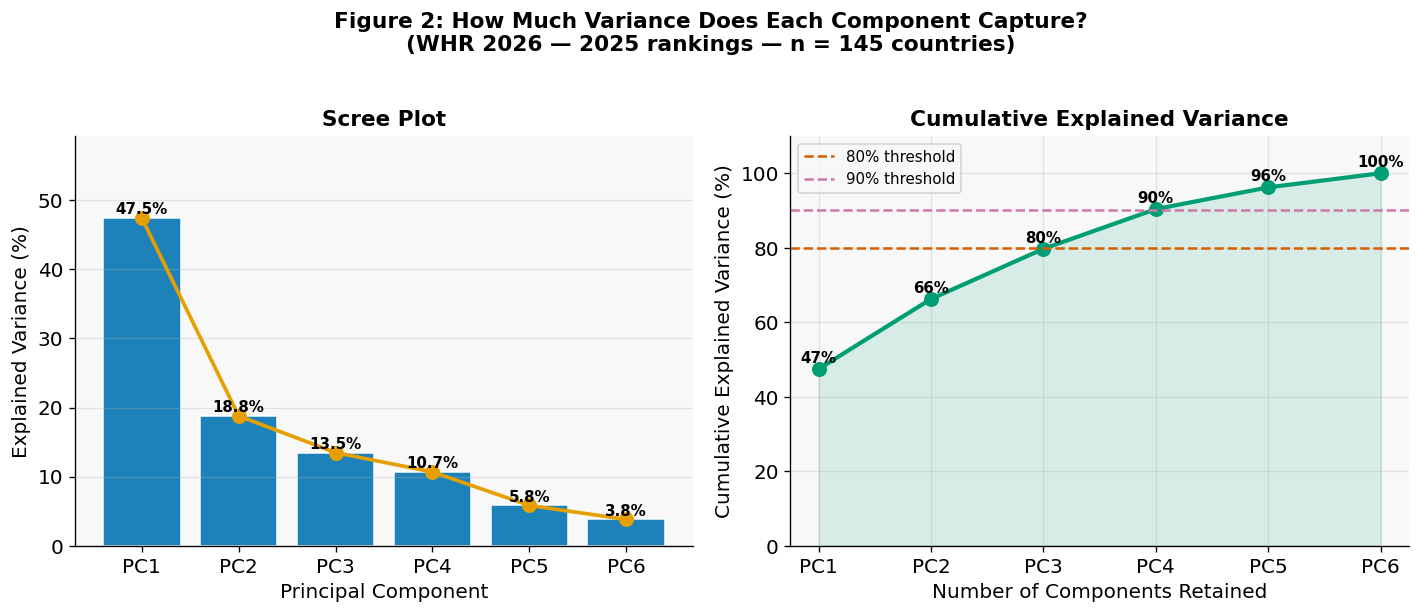

In [9]:
# ── Figure 2: Scree plot + cumulative explained variance ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
comps = np.arange(1, 7)

# Left: scree plot (variance per component)
bars = ax1.bar(comps, ev*100, color=CB[0], edgecolor='white', alpha=0.88)
ax1.plot(comps, ev*100, 'o-', color=CB[1], lw=2.2, ms=8)
for bar, val in zip(bars, ev*100):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.6,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot', fontweight='bold')
ax1.set_xticks(comps)
ax1.set_xticklabels([f'PC{i}' for i in comps])
ax1.set_ylim(0, max(ev*100) * 1.25)
ax1.grid(axis='y', alpha=0.3)

# Right: cumulative variance
ax2.plot(comps, cv*100, 'o-', color=CB[2], lw=2.5, ms=8)
ax2.fill_between(comps, cv*100, alpha=0.13, color=CB[2])
ax2.axhline(80, color=CB[5], ls='--', lw=1.5, label='80% threshold')
ax2.axhline(90, color=CB[3], ls='--', lw=1.5, label='90% threshold')
for i, val in enumerate(cv):
    ax2.annotate(f'{val*100:.0f}%', (comps[i], val*100 + 1.8),
                 ha='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('Number of Components Retained')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance', fontweight='bold')
ax2.set_xticks(comps)
ax2.set_xticklabels([f'PC{i}' for i in comps])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 110)

fig.suptitle('Figure 2: How Much Variance Does Each Component Capture?\n'
             '(WHR 2026 — 2025 rankings — n = 145 countries)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_scree_plot.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### What Figure 2 tells us

- **PC1 alone** captures 47.5% of all variance in the dataset.
- **PC1 + PC2 together** capture 66.2%.
- There is a clear **elbow** (sharp drop) after PC2 — every component after that adds less than 10%.

**Decision: retain 2 components.** This gives us a 2D picture that captures the dominant structure of the data. The 33.8% we discard is mostly measurement noise and country-specific quirks unrelated to any broader pattern.

---
## Step 6 — Interpret the Components (Loadings Analysis)

This is the most important step in any PCA — understanding **what the components actually mean**.

The **loadings matrix** shows how much each original feature contributes to each component:
- A loading close to **+1** means the feature strongly pushes countries in the positive direction of that component.
- A loading close to **−1** means it strongly pushes in the negative direction.
- A loading near **0** means the feature contributes very little to that component.

In [10]:
# Fit the final 2-component PCA model
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Store PC scores in the dataframe
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

pc1_pct = pca.explained_variance_ratio_[0] * 100
pc2_pct = pca.explained_variance_ratio_[1] * 100

# Build the loadings table
loadings = pd.DataFrame(
    pca.components_.T,
    index=SHORT,
    columns=['PC1', 'PC2']
)

print(f'PC1 explains {pc1_pct:.2f}% of variance')
print(f'PC2 explains {pc2_pct:.2f}% of variance')
print(f'Together:    {pc1_pct + pc2_pct:.2f}% retained\n')
print('Loadings (bold values ≥ 0.45 are the dominant contributors):')
print(loadings.round(3).to_string())

PC1 explains 47.45% of variance
PC2 explains 18.78% of variance
Together:    66.23% retained

Loadings (bold values ≥ 0.45 are the dominant contributors):
                   PC1    PC2
GDP              0.511 -0.264
Social Support   0.470 -0.221
Life Expectancy  0.496  0.005
Freedom          0.375  0.135
Generosity       0.059  0.848
Low Corruption   0.358  0.379


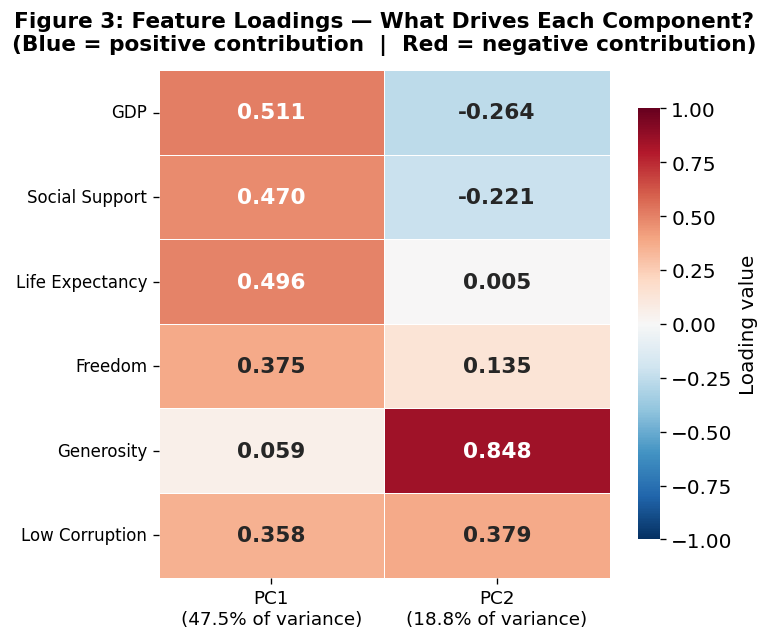

In [11]:
# ── Figure 3: Loadings heatmap ────────────────────────────────────────────────
pc_labels = [
    f'PC1\n({pc1_pct:.1f}% of variance)',
    f'PC2\n({pc2_pct:.1f}% of variance)'
]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    loadings, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.6, ax=ax,
    cbar_kws={'label': 'Loading value', 'shrink': 0.85},
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_xticklabels(pc_labels, rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title(
    'Figure 3: Feature Loadings — What Drives Each Component?\n'
    '(Blue = positive contribution  |  Red = negative contribution)',
    fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_loadings_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### What Figure 3 tells us — the key interpretation

**PC1 → "Overall Wellbeing" axis**

PC1 has strong positive loadings on:
- GDP (+0.511), Life Expectancy (+0.496), Social Support (+0.470), Freedom (+0.375), Low Corruption (+0.358)

A country scores high on PC1 when it is **wealthy, healthy, socially connected, free, and has trustworthy institutions**. These five features all pull in the same direction — PC1 is the main axis of global inequality in wellbeing.

---

**PC2 → "Generosity & Governance" axis**

PC2 is dominated almost entirely by Generosity (+0.848).

Crucially, GDP loads **negatively** on PC2 (−0.264). This means *wealthier countries score lower on PC2*, not higher. PC2 captures a dimension of civic generosity and institutional trust that is **partly independent of material wealth** — some countries are generous and have high trust not because they are rich, but for cultural or historical reasons.

This confirms the hint from the correlation heatmap: generosity really does occupy a different dimension.

---
## Step 7 — Visualise Countries in PCA Space

Now we can plot every country as a point in the 2D space defined by PC1 and PC2.

**The key point about this figure:** The algorithm was given *no geographic information*. The colours (world regions) are added afterwards for interpretation. Any clustering you see was discovered purely from the six numerical features.

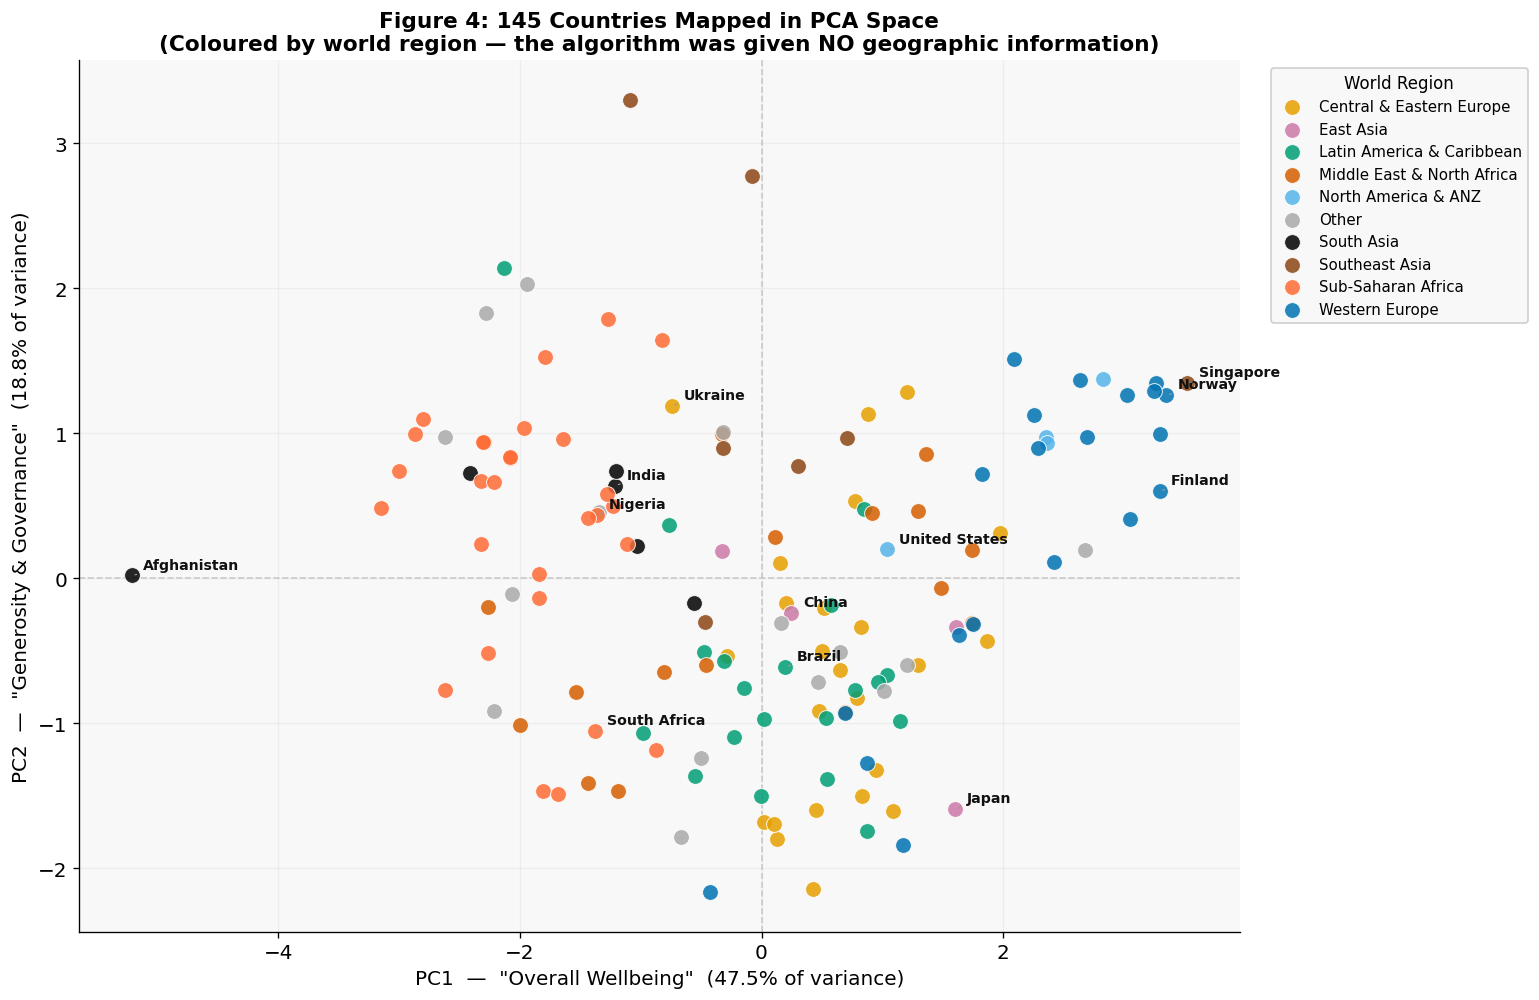

In [12]:
# ── Figure 4: Countries in PCA space ─────────────────────────────────────────
# These countries will be labelled directly on the chart for orientation
HIGHLIGHT = [
    'Finland', 'Afghanistan', 'United States', 'India',
    'China', 'Nigeria', 'Brazil', 'Norway',
    'Ukraine', 'Singapore', 'Japan', 'South Africa'
]

fig, ax = plt.subplots(figsize=(13, 8.5))

for region, grp in df.groupby('Region'):
    ax.scatter(
        grp['PC1'], grp['PC2'],
        c=REGION_COLOURS.get(region, '#AAAAAA'),
        label=region, s=90, alpha=0.85,
        edgecolors='white', linewidths=0.6, zorder=3
    )

for _, row in df[df['Country name'].isin(HIGHLIGHT)].iterrows():
    ax.annotate(
        row['Country name'],
        (row['PC1'], row['PC2']),
        textcoords='offset points', xytext=(7, 4),
        fontsize=8.5, fontweight='bold', color='#111111',
        arrowprops=dict(arrowstyle='-', color='#999999', lw=0.7)
    )

ax.axhline(0, color='#CCCCCC', lw=1, ls='--', zorder=1)
ax.axvline(0, color='#CCCCCC', lw=1, ls='--', zorder=1)
ax.set_xlabel(f'PC1  —  "Overall Wellbeing"  ({pc1_pct:.1f}% of variance)', fontsize=12)
ax.set_ylabel(f'PC2  —  "Generosity & Governance"  ({pc2_pct:.1f}% of variance)', fontsize=12)
ax.set_title(
    'Figure 4: 145 Countries Mapped in PCA Space\n'
    '(Coloured by world region — the algorithm was given NO geographic information)',
    fontsize=13, fontweight='bold'
)
ax.legend(
    title='World Region', bbox_to_anchor=(1.02, 1),
    loc='upper left', fontsize=9, title_fontsize=10, framealpha=0.92
)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_pca_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### What Figure 4 tells us

The geographic structure that emerges — without any region labels given to the algorithm — is striking:

| Region | Position in PCA space | Interpretation |
|---|---|---|
| **Western Europe** | Far right, moderate-to-high PC2 | High overall wellbeing + strong generosity/trust |
| **Sub-Saharan Africa** | Far left, lower PC2 | Low on both wellbeing axes |
| **Latin America** | Middle PC1, high PC2 | Lower income than PC1 predicts but very high generosity — the "Latin American happiness paradox" |
| **East Asia** | High PC1, mixed PC2 | Strong economy, lower self-reported generosity relative to income |
| **South Asia** | Low-to-middle PC1 | Large spread, reflecting diversity within the region |

---
## Step 8 — Validate the Results

### Does PC1 actually measure wellbeing?

We can test this by correlating PC1 with the **happiness score** — the variable we held out at the start and never used in the PCA.

If PC1 genuinely captures "Overall Wellbeing", it should correlate strongly with how countries rate their own lives.

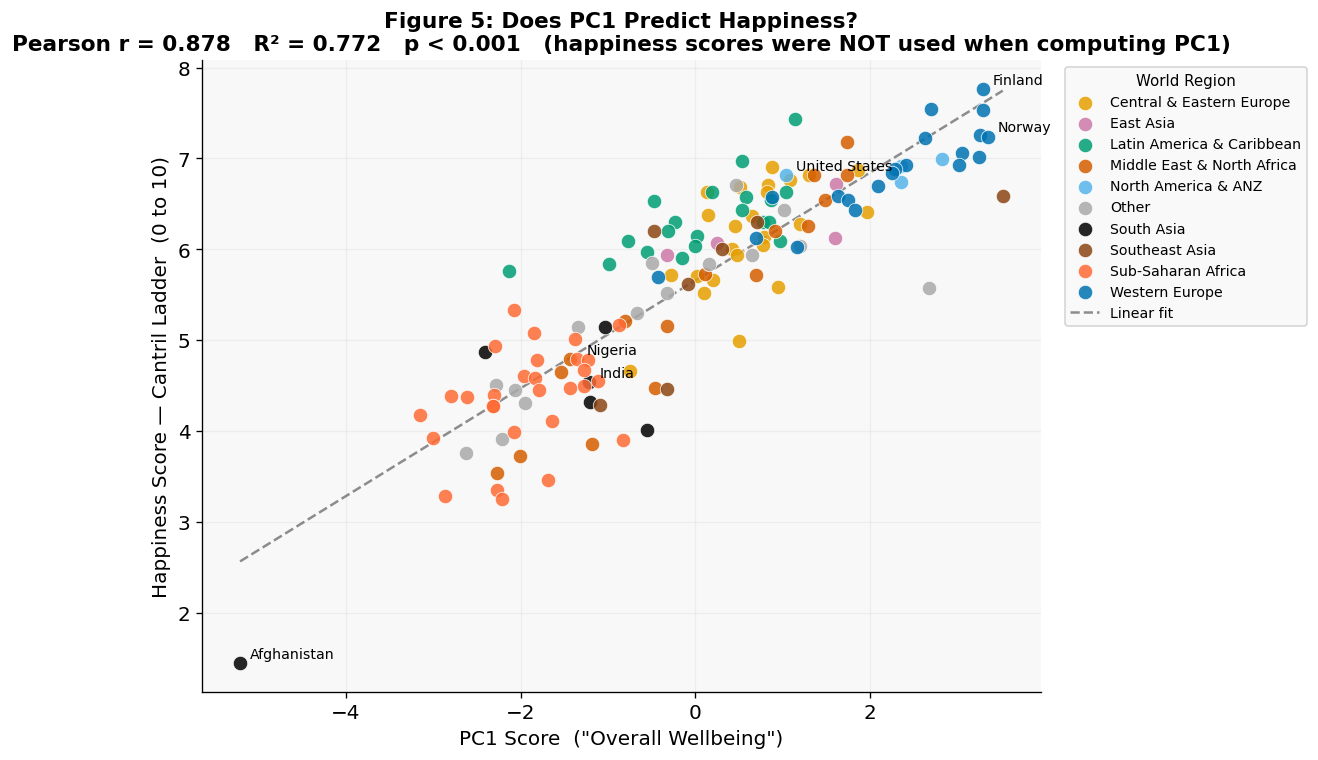

Pearson r  = 0.8784
R²         = 0.7717
p-value    = 1.04e-47

Result: PC1 explains 77.2% of variance in self-reported happiness
without ever having seen the happiness scores during fitting.


In [13]:
# ── Figure 5: PC1 vs self-reported happiness ──────────────────────────────────
r, p_value = stats.pearsonr(df['PC1'], df[TARGET])
slope, intercept = np.polyfit(df['PC1'], df[TARGET], 1)
x_fit = np.linspace(df['PC1'].min(), df['PC1'].max(), 200)

fig, ax = plt.subplots(figsize=(10, 6.5))

for region, grp in df.groupby('Region'):
    ax.scatter(
        grp['PC1'], grp[TARGET],
        c=REGION_COLOURS.get(region, '#AAAAAA'),
        label=region, s=75, alpha=0.85,
        edgecolors='white', linewidths=0.5, zorder=3
    )

ax.plot(x_fit, slope*x_fit + intercept, '--',
        color='#333333', lw=1.5, alpha=0.55, zorder=2, label='Linear fit')

for _, row in df[df['Country name'].isin(
        ['Finland', 'Afghanistan', 'United States', 'Nigeria', 'India', 'Norway'])].iterrows():
    ax.annotate(row['Country name'], (row['PC1'], row[TARGET]),
                textcoords='offset points', xytext=(6, 3), fontsize=8.5)

ax.set_xlabel('PC1 Score  ("Overall Wellbeing")', fontsize=12)
ax.set_ylabel('Happiness Score — Cantril Ladder  (0 to 10)', fontsize=12)
ax.set_title(
    f'Figure 5: Does PC1 Predict Happiness?\n'
    f'Pearson r = {r:.3f}   R² = {r**2:.3f}   p < 0.001   '
    f'(happiness scores were NOT used when computing PC1)',
    fontweight='bold'
)
ax.legend(title='World Region', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=8.5, title_fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_pc1_vs_happiness.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r  = {r:.4f}')
print(f'R²         = {r**2:.4f}')
print(f'p-value    = {p_value:.2e}')
print()
print(f'Result: PC1 explains {r**2*100:.1f}% of variance in self-reported happiness')
print('without ever having seen the happiness scores during fitting.')

### What Figure 5 tells us

**r = 0.88, R² = 0.77, p < 0.001**

A single axis derived from six features — with no access to the happiness scores — explains **77% of the variance** in how 145 countries rate their own lives. This is strong evidence that PC1 is capturing something real and meaningful.

The remaining 23% unexplained is where interesting research questions live. Notice that Latin American countries tend to sit *above* the regression line — they are happier than their PC1 score alone predicts, which aligns with their high PC2 (Generosity & Governance) scores.

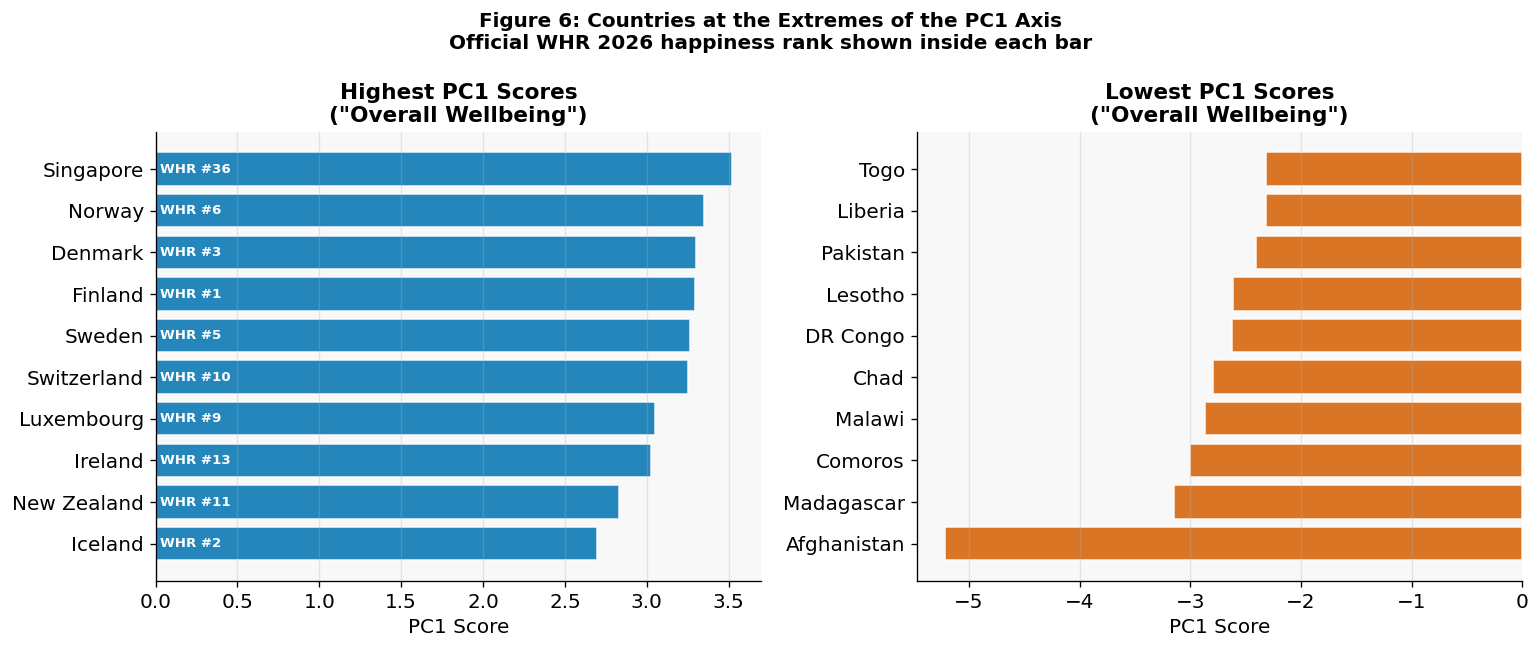

Top 5 countries by PC1:
Country name      PC1  Rank  Life evaluation (3-year average)
   Singapore 3.523118    36                             6.585
      Norway 3.350173     6                             7.242
     Denmark 3.300257     3                             7.539
     Finland 3.294262     1                             7.764
      Sweden 3.266833     5                             7.255

Bottom 5 countries by PC1:
Country name       PC1  Rank  Life evaluation (3-year average)
        Chad -2.799146   125                             4.385
      Malawi -2.867719   145                             3.284
     Comoros -3.002249   136                             3.925
  Madagascar -3.152404   132                             4.174
 Afghanistan -5.213169   147                             1.446


In [14]:
# ── Figure 6: Which countries sit at the extremes of PC1? ─────────────────────
top10 = df.nlargest(10,  'PC1')[['Country name', 'PC1', 'Rank', TARGET]].reset_index(drop=True)
bot10 = df.nsmallest(10, 'PC1')[['Country name', 'PC1', 'Rank', TARGET]].iloc[::-1].reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.barh(top10['Country name'], top10['PC1'],
         color=CB[0], alpha=0.85, edgecolor='white')
for i, (_, row) in enumerate(top10.iterrows()):
    ax1.text(0.03, i, f"WHR #{int(row['Rank'])}",
             va='center', fontsize=8, color='white', fontweight='bold')
ax1.set_xlabel('PC1 Score')
ax1.set_title('Highest PC1 Scores\n("Overall Wellbeing")', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

ax2.barh(bot10['Country name'], bot10['PC1'],
         color=CB[5], alpha=0.85, edgecolor='white')
ax2.set_xlabel('PC1 Score')
ax2.set_title('Lowest PC1 Scores\n("Overall Wellbeing")', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

fig.suptitle(
    'Figure 6: Countries at the Extremes of the PC1 Axis\n'
    'Official WHR 2026 happiness rank shown inside each bar',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig6_top_bottom_pc1.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 countries by PC1:')
print(top10[['Country name', 'PC1', 'Rank', TARGET]].head().to_string(index=False))
print()
print('Bottom 5 countries by PC1:')
print(bot10[['Country name', 'PC1', 'Rank', TARGET]].tail().to_string(index=False))

### What Figure 6 tells us

The top-10 PC1 countries are the same Nordic and Anglosphere nations that top the official WHR rankings every year (Finland, Iceland, Denmark, Norway...). The bottom-10 are nations facing severe poverty or conflict (Afghanistan, Malawi, Comoros...).

The close match between PC1 rankings and official WHR happiness rankings — even though PCA never saw the happiness scores — is the final confirmation that our components are meaningful.

---
## Step 9 — Ethical Considerations

### 1. The happiness score is subjective
The Cantril Ladder asks people to rate their own life. Cultural norms around expressing satisfaction differ across countries — someone who has never known anything different may rate a difficult life highly. Cross-national comparisons of self-reported wellbeing require careful interpretation.

### 2. Feature selection shapes what PCA finds
The six WHR features were chosen by the report's authors. Environmental quality, gender equity, mental health, and political rights are all absent. PCA can only discover structure in the data it is given — if an important dimension of wellbeing is not in the feature set, no component will capture it.

### 3. Correlation is not causation
PC1 correlates strongly with happiness, but this does not mean increasing GDP *causes* happiness. These features co-vary for complex historical and institutional reasons that PCA cannot disentangle. Making causal claims from this analysis would require different methods.

### 4. Some countries are missing from the data
Countries in extreme conflict or under authoritarian governance are most likely to have incomplete or unreliable survey data — yet these are precisely the places where understanding wellbeing is most urgent for global policy.

### 5. Two numbers cannot capture everything
Reducing six dimensions to two creates a seductive simplicity. A policymaker who treats PC1 as a single lever to pull is missing the point — what drives wellbeing in Finland is not the same as what would drive it in a low-income country with different historical, cultural, and institutional starting points.

---
## Summary

| Step | What we did | Key result |
|---|---|---|
| Load data | WHR 2026, 2025 rankings | 145 countries, 6 features |
| EDA | Pearson correlation matrix | GDP, Life Expectancy, Social Support strongly correlated (r > 0.6) |
| Standardise | `StandardScaler` | All features: mean = 0, std = 1 |
| Fit PCA (6 components) | Scree plot + eigenvalues | Clear elbow after PC2; 2 components retained |
| PC1 | Loadings analysis | 47.5% of variance — **"Overall Wellbeing"** |
| PC2 | Loadings analysis | 18.8% of variance — **"Generosity & Governance"** |
| Visualise | Regional scatter plot | Clear geographic clustering with **no region labels given** |
| Validate | Pearson correlation | PC1 vs happiness: **r = 0.88, R² = 0.77, p < 0.001** |
| Ethics | Discussion | 5 key limitations documented |

---

### References
1. Helliwell et al. (2026). *World Happiness Report 2026*. Oxford: Wellbeing Research Centre. https://worldhappiness.report/
2. Pearson, K. (1901). *Philosophical Magazine*, 2(11), 559–572. https://doi.org/10.1080/14786440109462720
3. Hotelling, H. (1933). *Journal of Educational Psychology*, 24(6), 417–441.
4. Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
5. Jolliffe & Cadima (2016). *Phil. Trans. R. Soc. A*, 374(2065). https://pmc.ncbi.nlm.nih.gov/articles/PMC4792409/
6. scikit-learn (2024). *PCA*. https://scikit-learn.org/stable/modules/decomposition.html#pca
7. Wong, B. (2011). *Nature Methods*, 8(6), 441. https://doi.org/10.1038/nmeth.1618